In [42]:
import bagpy
from bagpy import bagreader
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d
import plotly.graph_objects as go
import nbformat
import numpy as np


[INFO]  Data folder ./hibachi_log_2022-06-10-10-58-55 already exists. Not creating.
Index(['Time', 'header.seq', 'header.stamp.secs', 'header.stamp.nsecs',
       'header.frame_id', 'vector.x', 'vector.y', 'vector.z'],
      dtype='str')


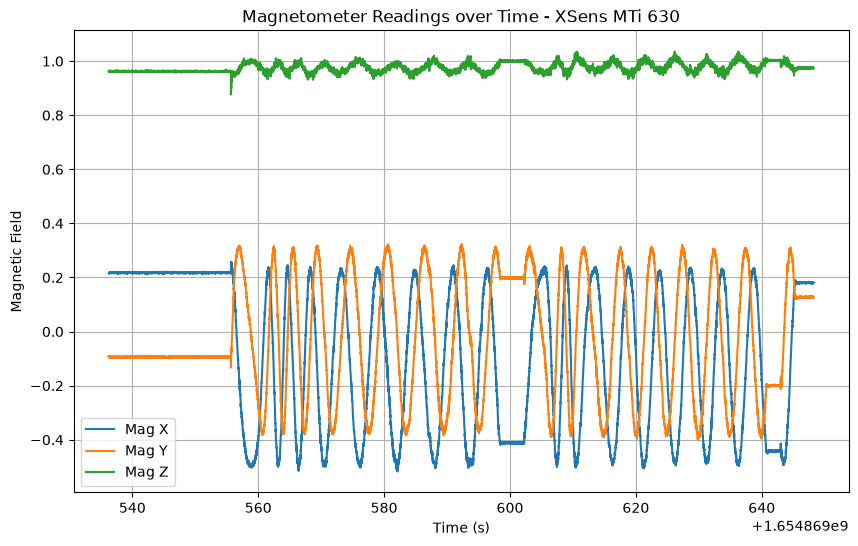

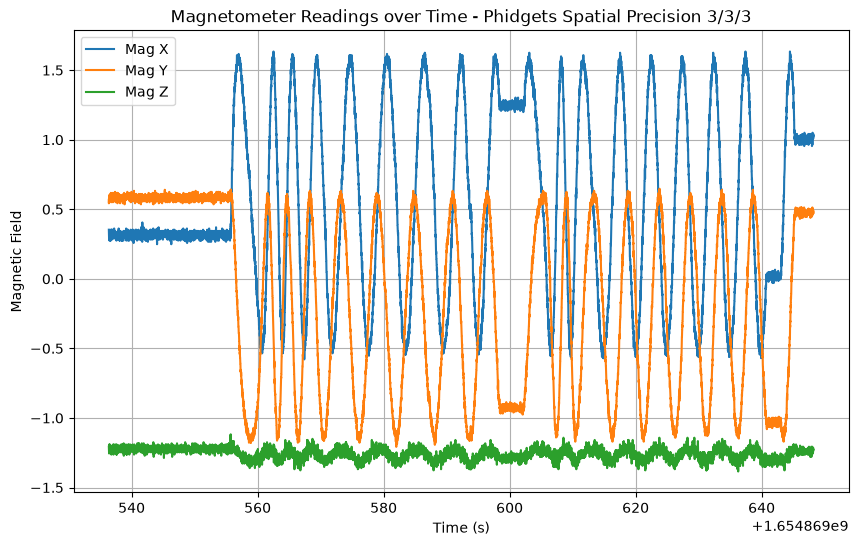

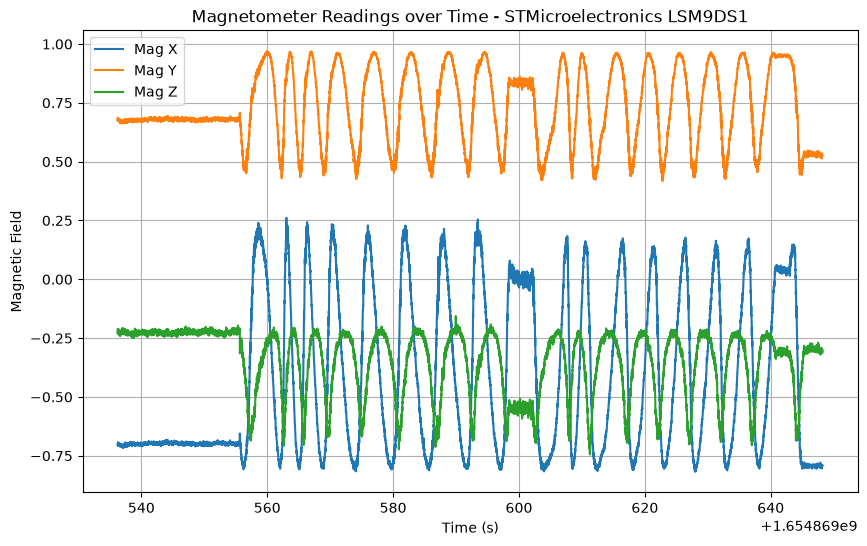

In [43]:
def plot_mag_data(_mag_data, imu_model=None, show=False):

    plot_title = "Magnetometer Readings over Time"
    if imu_model is not None:
        plot_title += " - " + imu_model

    plt.figure(figsize=(10, 6))
    try:        
        plt.plot(_mag_data['Time'], _mag_data['vector.x'], label='Mag X')
        plt.plot(_mag_data['Time'], _mag_data['vector.y'], label='Mag Y')
        plt.plot(_mag_data['Time'], _mag_data['vector.z'], label='Mag Z')
    except KeyError:
        plt.plot(_mag_data['Time'], _mag_data['magnetic_field.x'], label='Mag X')
        plt.plot(_mag_data['Time'], _mag_data['magnetic_field.y'], label='Mag Y')
        plt.plot(_mag_data['Time'], _mag_data['magnetic_field.z'], label='Mag Z')
    plt.xlabel('Time (s)')
    plt.ylabel('Magnetic Field')

    plt.title(plot_title)
    plt.legend()
    plt.grid(True)
    if show:
        plt.show()


# 1. Read the bag file
b = bagreader('./hibachi_log_2022-06-10-10-58-55.bag')

# 2. Get the specific topic's data (saves as a CSV automatically)
# To find your topic names, you can first run: print(b.topic_table)
# print(b.topic_table)

# The magnetometer topics are the following
# /mti_630_8A1G6/imu/mag ---> XSens MTi 630
# /phidgets_373223/imu/mag ---> Phidgets Spatial Precision 3/3/3
# /hibachi_imu_node/mag ---> STMicroelectronics LSM9DS1

mti_630_mag = b.message_by_topic(topic='/mti_630_8A1G6/imu/mag')
phidgets_mag = b.message_by_topic(topic='/phidgets_373223/imu/mag')
lsm9ds1_mag = b.message_by_topic(topic='/hibachi_imu_node/mag')


# 3.1. Load the data into a pandas DataFrame
df0 = pd.read_csv(mti_630_mag)
print(df0.columns)

# 3.2. Plot the data
plot_mag_data(df0, imu_model="XSens MTi 630", show=False)

# 4.1. Load the data into a pandas DataFrame
df1 = pd.read_csv(phidgets_mag)
# Pasar a [G]
df1['magnetic_field.x'] /= 1e-4
df1['magnetic_field.y'] /= 1e-4
df1['magnetic_field.z'] /= 1e-4

# 4.2. Plot the data
plot_mag_data(df1, imu_model="Phidgets Spatial Precision 3/3/3", show=False)

# 5.1. Load the data into a pandas DataFrame
df2 = pd.read_csv(lsm9ds1_mag)
# Pasar a [G]
df2['magnetic_field.x'] /= 1e-4
df2['magnetic_field.y'] /= 1e-4
df2['magnetic_field.z'] /= 1e-4

# 5.2. Plot the data
plot_mag_data(df2, imu_model="STMicroelectronics LSM9DS1", show=True)

In [44]:
def project_to_best_plane(df):
    """
    Proyecta las mediciones del magnetómetro al plano que mejor ajusta
    (PCA por mínimos cuadrados).

    Devuelve:
        projected_df : dataframe con columnas plane.x y plane.y
        center       : centroide (3,)
        R            : matriz de rotación 3x3
    """

    try:
        X = df[["vector.x",
                "vector.y",
                "vector.z"]].to_numpy()
    except KeyError:
        X = df[["magnetic_field.x",
                "magnetic_field.y",
                "magnetic_field.z"]].to_numpy()

    # Centroide
    center = X.mean(axis=0)

    # Datos centrados
    Xc = X - center

    # PCA mediante SVD
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)

    # Filas de Vt = ejes principales
    e1 = Vt[0]
    e2 = Vt[1]
    e3 = Vt[2]

    # Matriz de cambio de base
    R = np.vstack((e1, e2, e3))

    # Coordenadas en la nueva base
    Xrot = Xc @ R.T

    projected_df = df.copy()
    projected_df["plane.x"] = Xrot[:,0]
    projected_df["plane.y"] = Xrot[:,1]
    projected_df["plane.z"] = Xrot[:,2]

    return projected_df, center, R

In [45]:
df0_plane, center0, R0 = project_to_best_plane(df0)
df1_plane, center1, R1 = project_to_best_plane(df1)
df2_plane, center2, R2 = project_to_best_plane(df2)

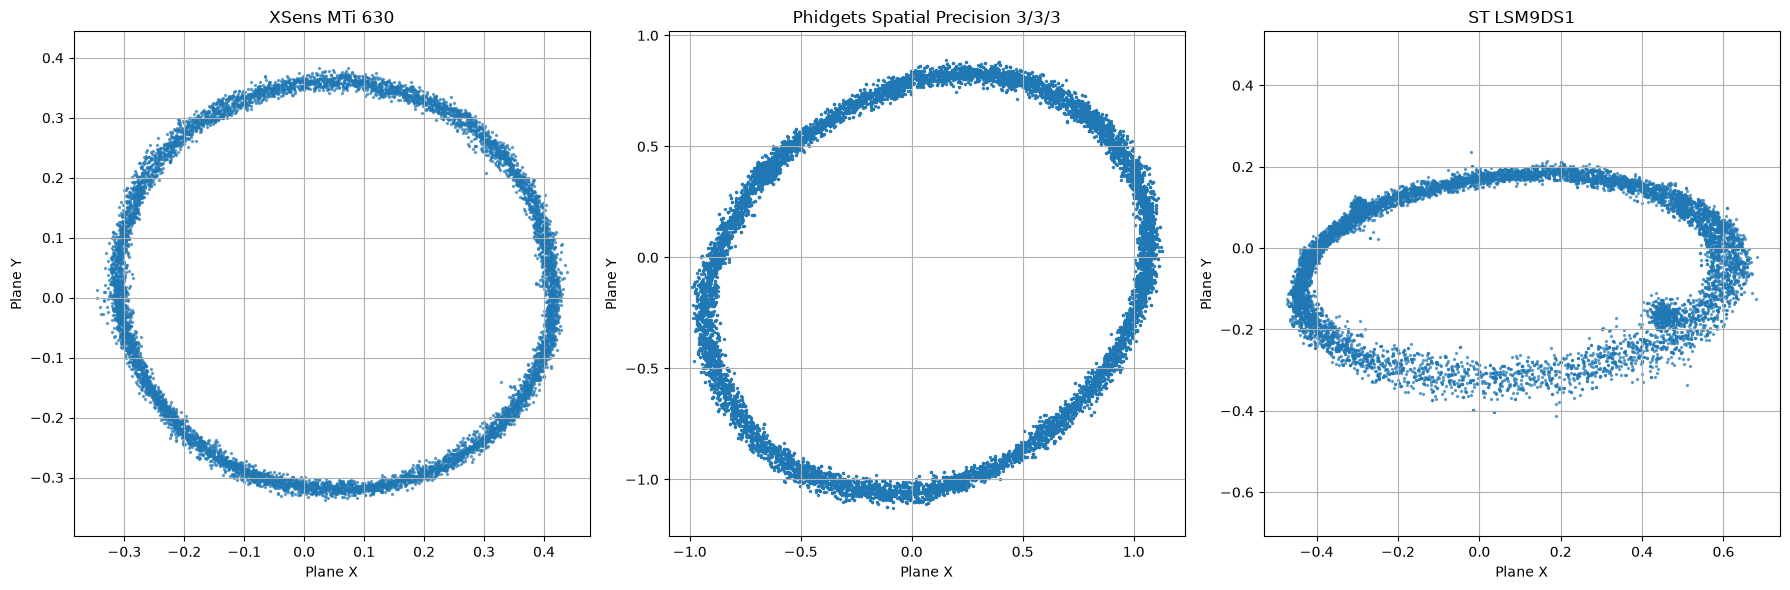

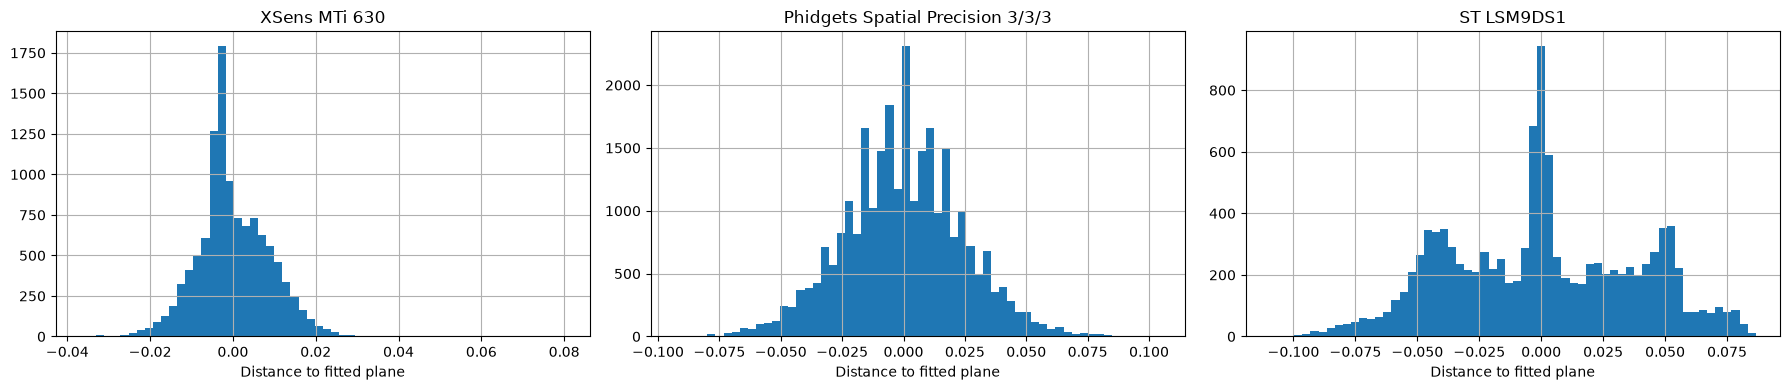

In [46]:
def plot_projected_planes(df0_plane, df1_plane, df2_plane):

    fig, ax = plt.subplots(1, 3, figsize=(18, 6))

    datasets = [
        (df0_plane, "XSens MTi 630"),
        (df1_plane, "Phidgets Spatial Precision 3/3/3"),
        (df2_plane, "ST LSM9DS1")
    ]

    for axis, (df, title) in zip(ax, datasets):

        axis.scatter(
            df["plane.x"],
            df["plane.y"],
            s=2,
            alpha=0.6
        )

        axis.set_title(title)
        axis.set_xlabel("Plane X")
        axis.set_ylabel("Plane Y")
        axis.axis("equal")
        axis.grid(True)

    plt.tight_layout()
    plt.show()
plot_projected_planes(df0_plane, df1_plane, df2_plane)

def plot_plane_residuals(df0_plane, df1_plane, df2_plane):

    fig, ax = plt.subplots(1, 3, figsize=(18, 4))

    datasets = [
        (df0_plane, "XSens MTi 630"),
        (df1_plane, "Phidgets Spatial Precision 3/3/3"),
        (df2_plane, "ST LSM9DS1")
    ]

    for axis, (df, title) in zip(ax, datasets):

        axis.hist(df["plane.z"], bins=60)

        axis.set_title(title)
        axis.set_xlabel("Distance to fitted plane")
        axis.grid(True)

    plt.tight_layout()
    plt.show()
plot_plane_residuals(df0_plane, df1_plane, df2_plane)

In [47]:
def plot_plane_fit(df, center, R, imu_model="IMU", plane_size=None):

    try:
        X = df[["vector.x", "vector.y", "vector.z"]].to_numpy()
    except KeyError:
        X = df[["magnetic_field.x",
                "magnetic_field.y",
                "magnetic_field.z"]].to_numpy()

    # Ejes del plano
    e1 = R[0]
    e2 = R[1]
    normal = R[2]

    # Tamaño del plano
    if plane_size is None:
        plane_size = np.max(np.linalg.norm(X - center, axis=1))

    u = np.linspace(-plane_size, plane_size, 20)
    v = np.linspace(-plane_size, plane_size, 20)
    U, V = np.meshgrid(u, v)

    plane = (
        center.reshape(3,1,1)
        + e1.reshape(3,1,1)*U
        + e2.reshape(3,1,1)*V
    )

    Xp = plane[0]
    Yp = plane[1]
    Zp = plane[2]

    fig = go.Figure()

    # Datos
    fig.add_trace(
        go.Scatter3d(
            x=X[:,0],
            y=X[:,1],
            z=X[:,2],
            mode="markers",
            marker=dict(
                size=2,
                color="blue"
            ),
            name="Measurements"
        )
    )

    # Plano
    fig.add_trace(
        go.Surface(
            x=Xp,
            y=Yp,
            z=Zp,
            opacity=0.5,
            showscale=False,
            name="Best-fit plane"
        )
    )

    # Centro
    fig.add_trace(
        go.Scatter3d(
            x=[center[0]],
            y=[center[1]],
            z=[center[2]],
            mode="markers",
            marker=dict(size=6, color="red"),
            name="Centroid"
        )
    )

    # Vector normal
    fig.add_trace(
        go.Scatter3d(
            x=[center[0], center[0] + normal[0]*plane_size],
            y=[center[1], center[1] + normal[1]*plane_size],
            z=[center[2], center[2] + normal[2]*plane_size],
            mode="lines",
            line=dict(color="red", width=6),
            name="Normal"
        )
    )

    fig.update_layout(
        title=f"PCA Plane Fit - {imu_model}",
        scene=dict(
            aspectmode="data",
            xaxis_title="X",
            yaxis_title="Y",
            zaxis_title="Z"
        ),
        width=900,
        height=700
    )

    fig.show()

plot_plane_fit(df0, center0, R0, "XSens MTi 630")
plot_plane_fit(df1, center1, R1, "Phidgets Spatial Precision 3/3/3")
plot_plane_fit(df2, center2, R2, "LSM9DS1")

In [48]:
def ls_ellipse(x, y):
    """
    Ajusta una elipse mediante mínimos cuadrados.

    Devuelve los parámetros:

        Ax² + Bxy + Cy² + Dx + Ey + F = 0

    con F = -1.
    """

    x = np.asarray(x).reshape(-1,1)
    y = np.asarray(y).reshape(-1,1)

    J = np.hstack((
        x*x,
        x*y,
        y*y,
        x,
        y
    ))

    K = np.ones_like(x)

    params = np.linalg.solve(J.T @ J, J.T @ K)

    A,B,C,D,E = params.flatten()

    return np.array([A,B,C,D,E,-1.0])

In [49]:
def polyToParams(v):
    """
    Convierte

        Ax²+Bxy+Cy²+Dx+Ey+F=0

    a

        centro
        ejes
        ángulo
        matriz de rotación
    """

    Amat = np.array([
        [v[0],      v[1]/2,   v[3]/2],
        [v[1]/2,    v[2],     v[4]/2],
        [v[3]/2,    v[4]/2,   v[5]]
    ])

    # Parte cuadrática
    A2 = Amat[:2,:2]

    ofs = np.array([
        v[3]/2,
        v[4]/2
    ])

    center = -np.linalg.inv(A2) @ ofs

    # Traslación al centro
    T = np.eye(3)
    T[2,0] = center[0]
    T[2,1] = center[1]

    R = T @ Amat @ T.T

    R2 = R[:2,:2]

    scale = -R[2,2]

    R2 = R2/scale

    eigval,eigvec = np.linalg.eig(R2)

    axes = np.sqrt(1/np.abs(eigval))

    print(eigvec)
    angle = np.degrees(
        np.arctan2(
            np.real(eigvec[1,0]),
            np.real(eigvec[0,0])
        )
    )

    rotation = eigvec

    return {
        "center": center, # Hard-Iron
        "axes": axes,
        "angle": angle,
        "rotation": rotation
    }

In [50]:
params0 = ls_ellipse(
    df0_plane["plane.x"],
    df0_plane["plane.y"]
)

params1 = ls_ellipse(
    df1_plane["plane.x"],
    df1_plane["plane.y"]
)

params2 = ls_ellipse(
    df2_plane["plane.x"],
    df2_plane["plane.y"]
)

ellipse0 = polyToParams(params0)
ellipse1 = polyToParams(params1)
ellipse2 = polyToParams(params2)

[[-0.98171264+0.j -0.19036883+0.j]
 [ 0.19036883+0.j -0.98171264+0.j]]
[[-0.80313873+0.j  0.59579206+0.j]
 [-0.59579206+0.j -0.80313873+0.j]]
[[-0.99743231+0.j  0.07161556+0.j]
 [-0.07161556+0.j -0.99743231+0.j]]


In [51]:
def plot_ellipse_fit(df_plane, ellipse, title=""):

    # Nube de puntos
    plt.figure(figsize=(6,6))
    plt.scatter(
        df_plane["plane.x"],
        df_plane["plane.y"],
        s=2,
        alpha=0.5,
        label="Measurements"
    )

    # Parámetros de la elipse
    center = ellipse["center"]
    axes = ellipse["axes"]
    theta = np.deg2rad(ellipse["angle"])

    a, b = axes

    t = np.linspace(0, 2*np.pi, 500)

    ellipse_local = np.vstack((
        a*np.cos(t),
        b*np.sin(t)
    ))

    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

    ellipse_global = R @ ellipse_local
    ellipse_global[0] += center[0]
    ellipse_global[1] += center[1]

    plt.plot(
        ellipse_global[0],
        ellipse_global[1],
        'r',
        linewidth=3,
        label="Least Squares Ellipse"
    )

    plt.scatter(
        center[0],
        center[1],
        color="red",
        marker="x",
        s=80,
        label="Center"
    )

    plt.axis("equal")
    plt.grid(True)
    plt.title(title)
    plt.xlabel("Plane X")
    plt.ylabel("Plane Y")
    plt.legend()

    plt.show()

def get_softiron_matrix(ellipse):

    R = ellipse["rotation"]

    a, b = ellipse["axes"]

    return R @ np.diag([1/a, 1/b]) @ R.T # Inversa del efecto soft-iron, corrige las mediciones

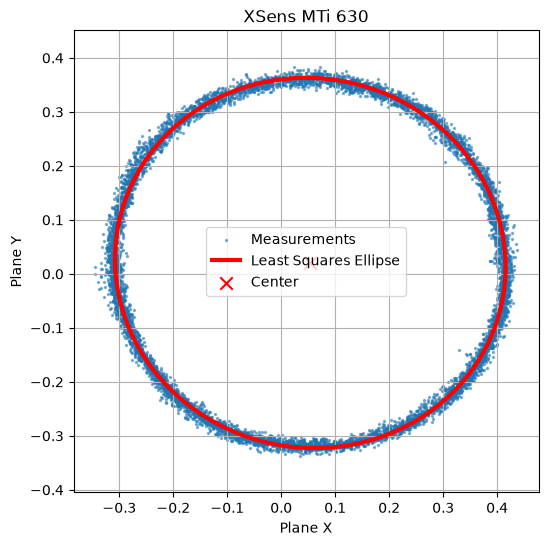

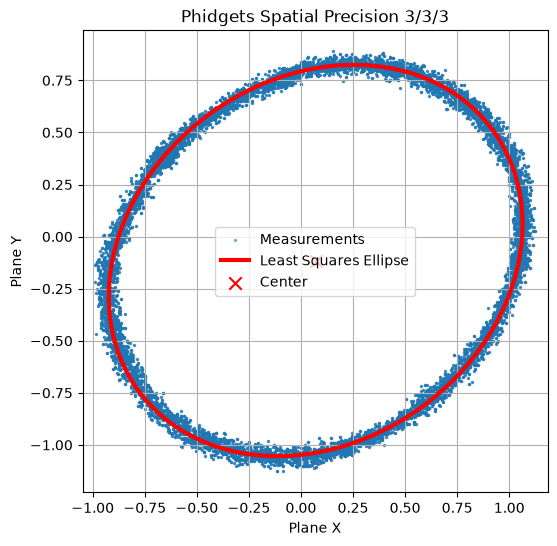

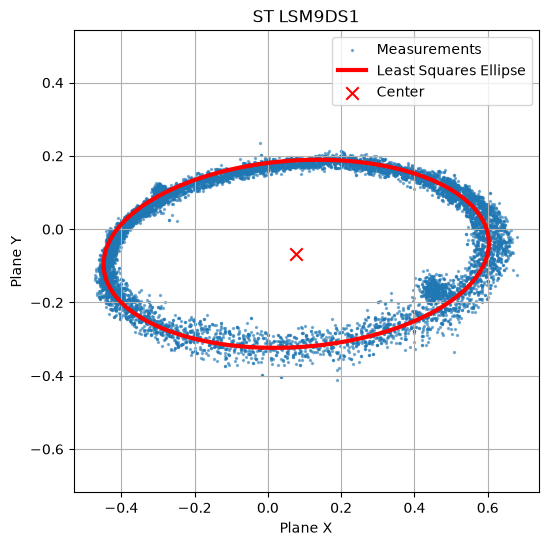

In [52]:
plot_ellipse_fit(df0_plane, ellipse0, "XSens MTi 630")
plot_ellipse_fit(df1_plane, ellipse1, "Phidgets Spatial Precision 3/3/3")
plot_ellipse_fit(df2_plane, ellipse2, "ST LSM9DS1")

In [53]:
def calibrate_plane(df_plane, ellipse):
    """
    Calibra las mediciones proyectadas al plano utilizando

        m_cal = S (m - b)

    donde
        b : hard-iron
        S : matriz de calibración del soft-iron
    """

    hard_iron = ellipse["center"]
    soft_iron = get_softiron_matrix(ellipse)

    pts = df_plane[["plane.x", "plane.y"]].to_numpy().T

    pts_cal = soft_iron @ (pts - hard_iron.reshape(2,1))

    df_cal = df_plane.copy()
    df_cal["plane.x"] = pts_cal[0]
    df_cal["plane.y"] = pts_cal[1]

    return df_cal

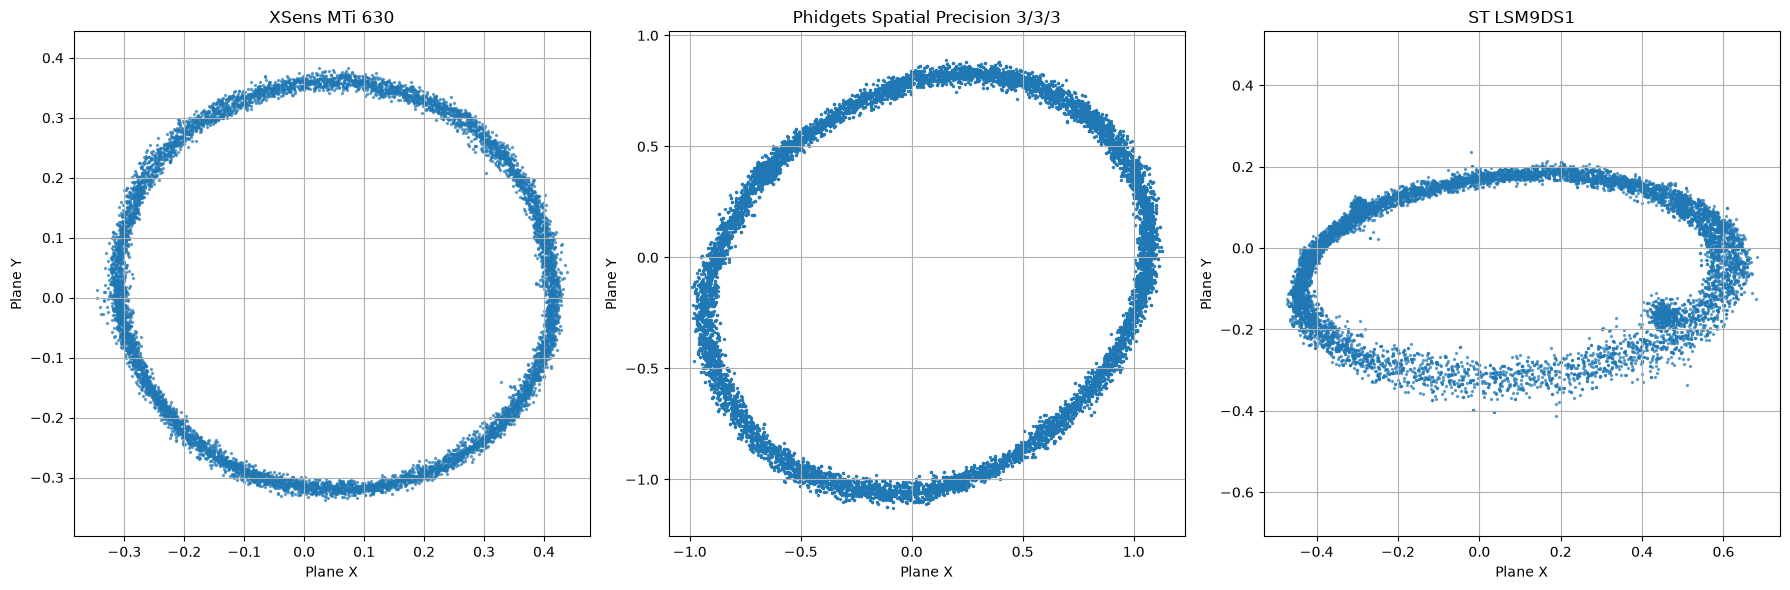

c:\Users\MATEOCRACK\Desktop\familia\santi\estimacion_tp\venv\Lib\site-packages\matplotlib\cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\MATEOCRACK\Desktop\familia\santi\estimacion_tp\venv\Lib\site-packages\matplotlib\collections.py:205: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


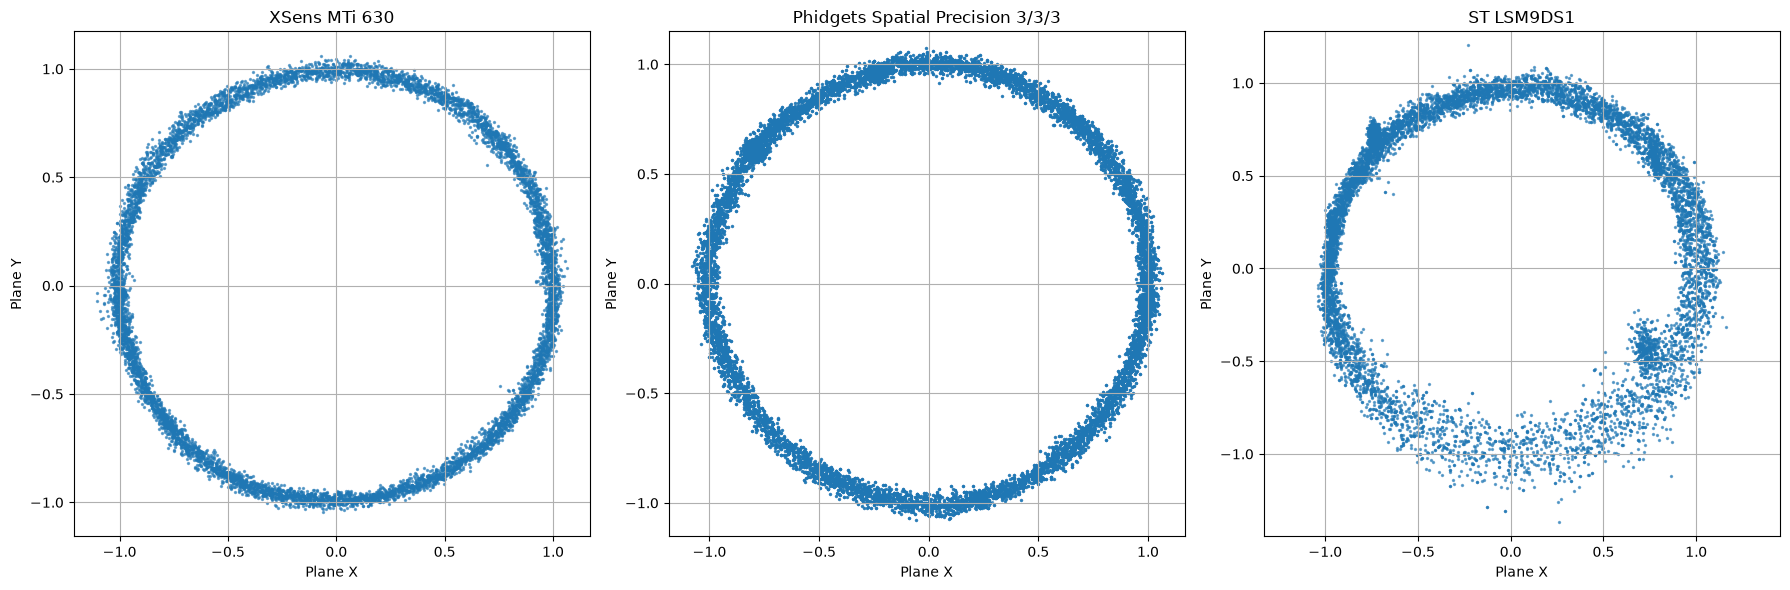

In [54]:
df0_cal = calibrate_plane(df0_plane, ellipse0)
df1_cal = calibrate_plane(df1_plane, ellipse1)
df2_cal = calibrate_plane(df2_plane, ellipse2)

plot_projected_planes(df0_plane, df1_plane, df2_plane)

plot_projected_planes(df0_cal, df1_cal, df2_cal)